# Which countries dominate the Winter Olympics?

The Winter Olympics feel global, but the medal table often looks the same year on year.
So I used **`results.csv`** (a full Olympics results dataset) and filtered to **Winter Games** to ask:

1. Who dominates the Winter Olympics?
2. Which sports “belong” to a small set of countries?


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv", low_memory=False)

df.columns = [c.strip() for c in df.columns]

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Columns: ['Games', 'Event', 'Team', 'Pos', 'Medal', 'As', 'athlete_id', 'NOC', 'Discipline', 'Nationality', 'Unnamed: 7']
Shape: (308408, 11)


,Games,Event,Team,Pos,Medal,As,athlete_id,NOC,Discipline,Nationality,Unnamed: 7
0,1912 Summer Olympics,"Singles, Men (Olympic)",NaN,=17,NaN,Jean-François Blanchy,1,FRA,Tennis,NaN,NaN
1,1912 Summer Olympics,"Doubles, Men (Olympic)",Jean Montariol,DNS,NaN,Jean-François Blanchy,1,FRA,Tennis,NaN,NaN
2,1920 Summer Olympics,"Singles, Men (Olympic)",NaN,=32,NaN,Jean-François Blanchy,1,FRA,Tennis,NaN,NaN
3,1920 Summer Olympics,"Doubles, Mixed (Olympic)",Jeanne Vaussard,=8,NaN,Jean-François Blanchy,1,FRA,Tennis,NaN,NaN
4,1920 Summer Olympics,"Doubles, Men (Olympic)",Jacques Brugnon,4,NaN,Jean-François Blanchy,1,FRA,Tennis,NaN,NaN


In [19]:
df["season"] = df["Games"].astype(str).str.extract(r"(Summer|Winter)", expand=False)
df["year"]   = df["Games"].astype(str).str.extract(r"(\d{4})", expand=False).astype("Int64")

season_col = "season"
year_col   = "year"
noc_col    = "NOC"
sport_col  = "Discipline"
medal_col  = "Medal"

winter_df = df[df[season_col].eq("Winter")].copy()
winter_df = winter_df[winter_df[medal_col].notna()].copy()

print("Winter medal rows:", winter_df.shape)
winter_df[[year_col, noc_col, sport_col, medal_col]].head()

Winter medal rows: (7655, 13)


,year,NOC,Discipline,Medal
13177,1932,USA,Bobsleigh (Bobsleigh),Gold
23439,2002,CAN,Speed Skating (Skating),Bronze
23441,2006,CAN,Speed Skating (Skating),Gold
23442,2006,CAN,Speed Skating (Skating),Silver
23444,2010,CAN,Speed Skating (Skating),Bronze


## Dominance changes: the Winter Olympics have changing periods

Instead of asking “who wins most medals?”, I looked at how dominance changes over time.

If the Winter Olympics were truly stable, the same countries would lead every decade.
But if there are eras, the leaderboard should reshuffle.


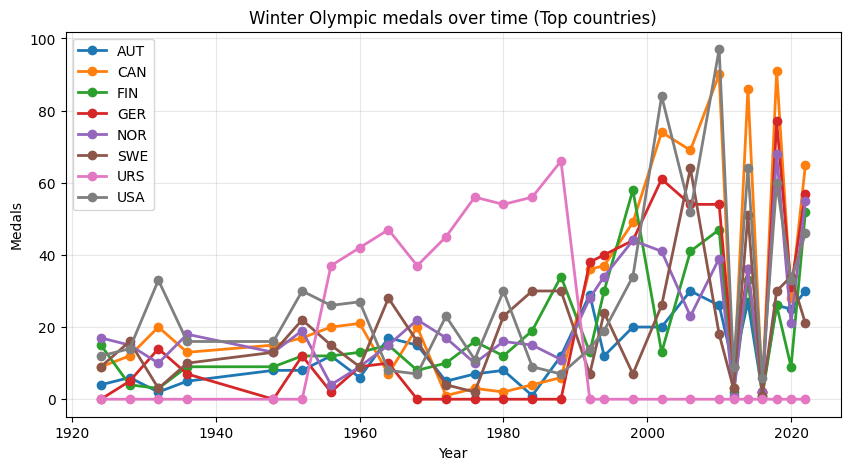

In [18]:
top_n = 8
top_nocs = winter_df[noc_col].value_counts().head(top_n).index.tolist()

medals_by_year = (
    winter_df[winter_df[noc_col].isin(top_nocs)]
    .groupby([year_col, noc_col])[medal_col]
    .size()
    .reset_index(name="medals")
)

pivot = medals_by_year.pivot(index=year_col, columns=noc_col, values="medals").fillna(0).sort_index()

plt.figure(figsize=(10,5))
for c in pivot.columns:
    plt.plot(pivot.index, pivot[c], marker="o", linewidth=2, label=c)
plt.title("Winter Olympic medals over time (Top countries)")
plt.xlabel("Year")
plt.ylabel("Medals")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

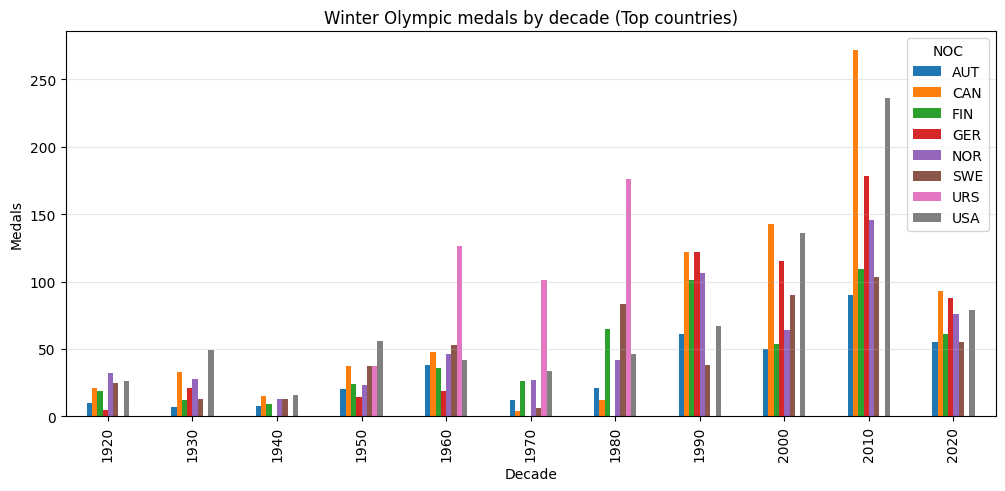

In [14]:
winter_df["decade"] = (winter_df[year_col] // 10) * 10

decade_counts = (
    winter_df[winter_df[noc_col].isin(top_nocs)]
    .groupby(["decade", noc_col])[medal_col]
    .size()
    .reset_index(name="medals")
    .pivot(index="decade", columns=noc_col, values="medals")
    .fillna(0)
    .sort_index()
)

decade_counts.plot(kind="bar", figsize=(12,5))
plt.title("Winter Olympic medals by decade (Top countries)")
plt.xlabel("Decade")
plt.ylabel("Medals")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Some sports are “owned” by a few countries

The Winter Olympics are not one competition — they’re many sports.

So I asked: for each sport, do medals spread across lots of countries or concentrate in a few?


In [17]:
top_sports = winter_df[sport_col].value_counts().head(8).index.tolist()

sport_country = (
    winter_df[winter_df[sport_col].isin(top_sports)]
    .groupby([sport_col, noc_col])[medal_col]
    .size()
    .reset_index(name="medals")
)

shares = []
for s in top_sports:
    sub = sport_country[sport_country[sport_col] == s].sort_values("medals", ascending=False)
    total = sub["medals"].sum()
    top3 = sub["medals"].head(3).sum()
    shares.append({"sport": s, "top3_share": top3/total if total else np.nan, "total_medals": total})

shares_df = pd.DataFrame(shares).sort_values("top3_share", ascending=False)
shares_df

,sport,top3_share,total_medals
7,Short Track Speed Skating (Skating),0.637850,428
6,Bobsleigh (Bobsleigh),0.577007,461
1,Cross Country Skiing (Skiing),0.552632,950
0,Ice Hockey (Ice Hockey),0.523429,1878
3,Alpine Skiing (Skiing),0.516014,562
4,Biathlon,0.473310,562
2,Speed Skating (Skating),0.444892,744
5,Figure Skating (Skating),0.440644,497


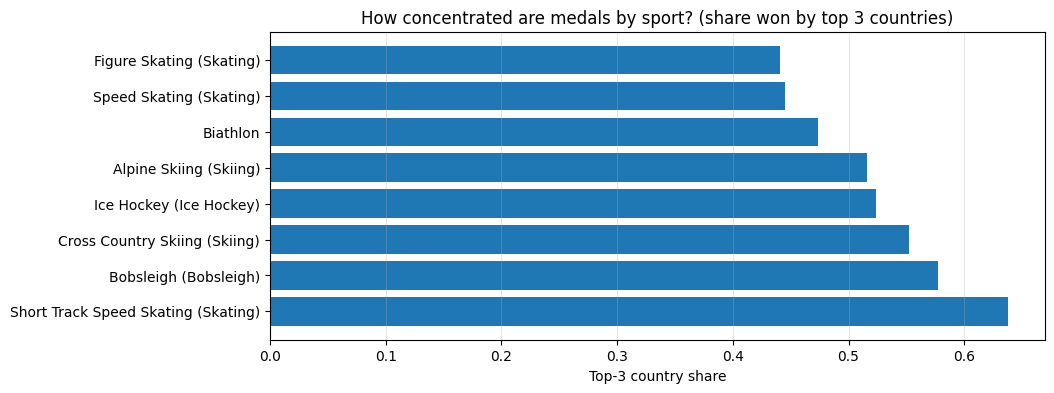

In [16]:
plt.figure(figsize=(10,4))
plt.barh(shares_df["sport"], shares_df["top3_share"])
plt.title("How concentrated are medals by sport? (share won by top 3 countries)")
plt.xlabel("Top-3 country share")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## Conclusion

Two things stood out:

* **Dominance comes in eras** : the “top” isn’t fixed forever.
* **Some sports are highly concentrated**, meaning a small set of countries win a huge share of medals.

So the Winter Olympics aren’t just about “best athletes.”
They’re also about infrastructure, climate, national investment, and which sports a country can realistically build pipelines for.

In other words: it’s a competition — but it’s not starting from an equal baseline.
